Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu{cuda_version}
Looking in links: https://data.pyg.org/whl/torch-{torch.__version__}+{cu}.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.7 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl size=547368 sha256=cb1919b3bbd9f0ccce21fe002d08a406e2318575488adf38b8bf0a6d904ea666
  Stored in directory: /root/.cache/pip/wheels/b8/d4/0e/a80af2465354ea7355a2c153b11af2da739cfcf08b6c0b28e2
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl size=1127937 sha256=18faf1d8b2144779e5e5f76b161b6

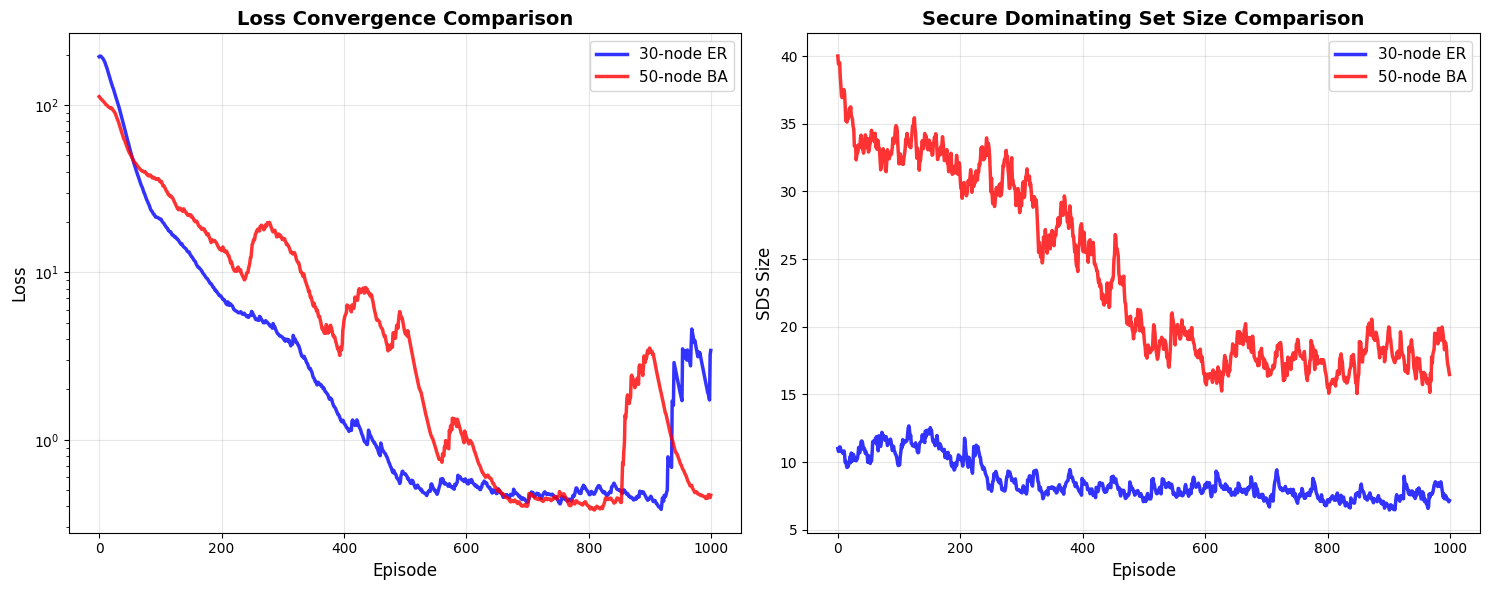


COMPARISON SUMMARY
30-node ER graphs:
  - Success Rate: 99.9%
  - Average SDS Size: 7.48
  - Final Loss: 4.2533

50-node BA graphs:
  - Success Rate: 96.6%
  - Average SDS Size: 17.50
  - Final Loss: 0.4758

Analysis:
  - Node ratio (50/30): 1.67
  - SDS size ratio (BA/ER): 2.34
  - Efficiency comparison: ER more efficient


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Install torch_geometric and its dependencies.
# Replace {CUDA_VERSION} with your CUDA version (e.g., cu116, cu117, cu118, cu121).
# If you don't have a CUDA-enabled GPU or don't want to use it, use 'cpu'.
!pip install torch_geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}+{cu}.html --extra-index-url https://download.pytorch.org/whl/cu{cuda_version}

from torch_geometric.utils import from_networkx, to_dense_adj
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from scipy import stats

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



class MPNNLayer(MessagePassing):
    """Message Passing Neural Network Layer for graph convolution"""

    def __init__(self, in_dim, edge_dim, hidden_dim):
        super(MPNNLayer, self).__init__(aggr='add')
        self.theta1 = nn.Linear(in_dim * 2 + edge_dim, hidden_dim)
        self.theta2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        """Compute messages between connected nodes"""
        m = torch.cat([x_i, x_j, edge_attr], dim=1)
        m = F.relu(self.theta1(m))
        m = F.relu(self.theta2(m))
        return m

class VertexEdgeEmbedding(nn.Module):
    """Creates embeddings for vertices considering edge information"""

    def __init__(self, node_feat_dim, adj_dim, hidden_dim):
        super(VertexEdgeEmbedding, self).__init__()
        self.f_theta = nn.Linear(node_feat_dim + adj_dim, hidden_dim)
        self.edge_theta = nn.Linear(hidden_dim + adj_dim, hidden_dim)

    def forward(self, node_feat, adj):

        A_norm = adj / (adj.sum(dim=-1, keepdim=True) + 1e-6)


        vf_A = torch.cat([node_feat, adj], dim=1)
        f = F.relu(self.f_theta(vf_A))


        combined = torch.cat([f, A_norm], dim=1)
        e = F.relu(self.edge_theta(combined))
        return e

class FullMPNN(nn.Module):
    """Complete Message Passing Neural Network"""

    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_nodes, num_layers=3):
        super(FullMPNN, self).__init__()
        self.vertex_embedder = VertexEdgeEmbedding(node_feat_dim, num_nodes, hidden_dim)
        self.gnn_layers = nn.ModuleList([
            MPNNLayer(node_feat_dim if i == 0 else hidden_dim, hidden_dim, hidden_dim)
            for i in range(num_layers)
        ])

    def forward(self, x, edge_index, adj):
        # Create edge embeddings
        edge_attr_node_level = self.vertex_embedder(x, adj)
        num_edges = edge_index.size(1)
        edge_attr_per_edge = edge_attr_node_level.new_zeros((num_edges, edge_attr_node_level.size(-1)))

        # Apply GNN layers
        x = self.gnn_layers[0](x, edge_index, edge_attr_per_edge)
        for i in range(1, len(self.gnn_layers)):
            x = self.gnn_layers[i](x, edge_index, edge_attr_per_edge)
        return x

class GNNQNetwork(nn.Module):
    """Q-Network combining GNN with Q-value output"""

    def __init__(self, gnn, hidden_dim):
        super(GNNQNetwork, self).__init__()
        self.gnn = gnn
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, data, state_batch):
        adj = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0]
        x_embed = self.gnn(data.x, data.edge_index, adj)
        q_values = self.output_layer(x_embed).squeeze(-1)
        return q_values.unsqueeze(0)


def get_neighbors(node, adj_matrix):
    """Get neighbors of a node from adjacency matrix"""
    return (adj_matrix[node] > 0).nonzero(as_tuple=True)[0]

def is_securely_dominated(node, dominating_set, adj_matrix):
    """Check if a node is securely dominated by the dominating set."""
    # Convert state tensor to set for easier operations
    if isinstance(dominating_set, torch.Tensor):
        dom_set = set((dominating_set >= 1).nonzero(as_tuple=True)[0].cpu().numpy())
    else:
        dom_set = set(dominating_set)

    # If the node itself is in the dominating set, it's securely dominated
    if node in dom_set:
        return True

    # Check if any dominating neighbor can securely dominate this node
    neighbors = get_neighbors(node, adj_matrix)

    for neighbor in neighbors:
        if neighbor.item() in dom_set:  # This neighbor is in the dominating set
            # For secure domination, the dominating neighbor must have at least
            # one other neighbor (besides the current node being checked)
            neighbor_neighbors = get_neighbors(neighbor, adj_matrix)

            # Count other neighbors (excluding the node being dominated)
            other_neighbors = [n for n in neighbor_neighbors if n.item() != node]

            # The dominating node can securely dominate if it has other connections
            if len(other_neighbors) > 0:
                return True

    return False

def is_secure_dominating_set_complete(state, adj_matrix):
    """Check if the current state forms a complete secure dominating set."""
    num_nodes = adj_matrix.shape[0]

    for node in range(num_nodes):
        if not is_securely_dominated(node, state, adj_matrix):
            return False

    return True

def sds_reward_function(state, action, adj_matrix, weight_vector=None):
    """Improved reward function for secure dominating set learning."""
    num_nodes = adj_matrix.shape[0]

    # Create new state after action
    new_state = state.clone()
    new_state[action] = 1

    # Check if action creates redundancy (node already selected)
    if state[action] == 1:  # Already selected
        return -10.0

    # Calculate domination coverage before and after
    dom_before = sum(1 for i in range(num_nodes) if is_securely_dominated(i, state, adj_matrix))
    dom_after = sum(1 for i in range(num_nodes) if is_securely_dominated(i, new_state, adj_matrix))

    coverage_increase = dom_after - dom_before

    # Base reward for coverage increase
    reward = coverage_increase * 5.0

    # Check if we've completed a secure dominating set
    if is_secure_dominating_set_complete(new_state, adj_matrix):
        set_size = (new_state >= 1).sum().item()
        # Reward inversely proportional to set size (encourage smaller sets)
        size_bonus = max(0, 50 - set_size * 2)
        reward += 100.0 + size_bonus

    # Penalty for large sets (encourage efficiency)
    current_size = (new_state >= 1).sum().item()
    if current_size > num_nodes * 0.7:  # If more than 70% of nodes selected
        reward -= 20.0

    # Small penalty to encourage exploration of smaller solutions
    reward -= 0.5

    return reward



def mask_state(state, action, edge_index, num_nodes):
    """Update state by selecting a node for the dominating set"""
    new_state = state.clone()
    new_state[action] = 1
    return new_state

def reward_fn(state, action, adj_matrix, weight_vector):
    """Wrapper for reward function"""
    return sds_reward_function(state, action, adj_matrix, weight_vector)

def greedy_policy(q_values, state, epsilon=0.1):
    """Epsilon-greedy action selection"""
    candidates = (state < 1).nonzero(as_tuple=True)[0]
    if len(candidates) == 0:
        return torch.randint(0, len(state), (1,)).item()

    if np.random.rand() < epsilon:
        return np.random.choice(candidates.cpu().numpy()).item()

    q_values[~(state < 1)] = -float('inf')
    return torch.argmax(q_values).item()

class Transition:
    """Store transition information for replay buffer"""
    def __init__(self, state, action, reward, next_state, done, data):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.done = done
        self.data = data

class ReplayBuffer:
    """Experience replay buffer for DQN"""
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []

    def push(self, transition):
        self.buffer.append(transition)
        self.buffer = self.buffer[-self.capacity:]

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        return [self.buffer[i] for i in indices]

    def __len__(self):
        return len(self.buffer)

def train_step(batch, q_net, target_q_net, optimizer, gamma=0.95):
    """Single training step for DQN"""
    q_values, target_q_values = [], []

    for transition in batch:
        # Current Q-value
        q_vals = q_net(transition.data, transition.state.unsqueeze(0))[0]
        q_val = q_vals[transition.action]

        # Target Q-value
        with torch.no_grad():
            next_q_vals = target_q_net(transition.data, transition.next_state.unsqueeze(0))[0]
            if next_q_vals.numel() == 0:
                best_next_q = torch.tensor(0.0, device=next_q_vals.device)
            else:
                best_next_q = torch.max(next_q_vals)

            reward_tensor = torch.tensor(transition.reward, device=q_val.device)
            zero_tensor = torch.tensor(0.0, device=q_val.device)

            target_val = reward_tensor + (zero_tensor if transition.done else
                        gamma * best_next_q)

        q_values.append(q_val)
        target_q_values.append(torch.clamp(target_val.detach(), -20.0, 20.0))

    if not q_values:
        return 0.0

    loss = F.mse_loss(torch.stack(q_values), torch.stack(target_q_values))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
    optimizer.step()
    return loss.item()

def soft_update(target_net, source_net, tau=0.005):
    """Soft update of target network parameters"""
    with torch.no_grad():
        for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
            target_param.data.mul_(1.0 - tau).add_(tau * source_param.data)


def generate_graph(n=40, p=0.2, graph_type='ER'):
    """Generate random graphs for training"""
    if graph_type == 'ER':
        G = nx.erdos_renyi_graph(n=n, p=p)
    else:  # Barabási-Albert
        m = min(2, n-1 if n > 1 else 1)
        G = nx.barabasi_albert_graph(n=n, m=m)

    # Handle empty graph case
    if len(G) == 0 and n > 0:
        print(f"Warning: Generated empty graph for n={n}.")
        G = nx.Graph()
        for i in range(n):
            G.add_node(i)

    # Add node features
    for v in G.nodes():
        G.nodes[v]['x'] = [0.0]

    data = from_networkx(G)
    data.num_nodes = len(G)
    return data

def smooth_curve(values, weight=0.9):
    """Smooth learning curves for visualization"""
    if not values:
        return []
    smoothed, last = [], values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed


def run_single_experiment(n_nodes, graph_type, episodes=200):
    """Run a single experiment configuration"""

    print(f"\nRunning experiment: {n_nodes}-node {graph_type} graphs")
    print("-" * 50)

    hidden_dim = 32

    # Initialize networks
    gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    q_net = GNNQNetwork(gnn, hidden_dim).to(device)
    target_gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    target_q_net = GNNQNetwork(target_gnn, hidden_dim).to(device)
    target_q_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-4)

    buffer = ReplayBuffer(capacity=1000)

    # Modified to track loss per episode
    episode_losses = []  # Track average loss per episode
    sds_sizes, rewards_history = [], []
    success_episodes = 0
    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.995

    for episode in range(episodes):
        # Generate graph with appropriate parameters
        if graph_type == 'ER':
            data = generate_graph(n=n_nodes, graph_type='ER', p=0.3)
        else:  # BA
            data = generate_graph(n=n_nodes, graph_type='BA')

        num_nodes_actual = data.num_nodes

        if num_nodes_actual != n_nodes:
            continue

        data.x = torch.zeros((num_nodes_actual, 1)).to(device)
        data = data.to(device)
        state = torch.zeros(num_nodes_actual).to(device)
        adj = to_dense_adj(data.edge_index, max_num_nodes=num_nodes_actual)[0]

        if adj.shape[0] != num_nodes_actual or adj.shape[1] != num_nodes_actual:
            continue

        actions_taken = []
        episode_reward = 0
        episode_loss_values = []  # Track losses within this episode
        done = False
        steps = 0
        max_steps = n_nodes  # Prevent infinite loops

        while not done and steps < max_steps:
            q_vals = q_net(data, state.unsqueeze(0))[0]
            action = greedy_policy(q_vals.clone(), state, epsilon)
            actions_taken.append(action)
            next_state = mask_state(state, action, data.edge_index, num_nodes_actual)
            r = reward_fn(state, action, adj, torch.ones(num_nodes_actual, device=device))

            episode_reward += r

            # Check if we have a complete secure dominating set
            done = is_secure_dominating_set_complete(next_state, adj)

            if done:
                success_episodes += 1

            # Safety check: if we've selected too many nodes, force termination
            if (next_state >= 1).sum().item() >= num_nodes_actual * 0.8:
                done = True
                r -= 50.0  # Large penalty for inefficient solution

            buffer.push(Transition(state, action, r, next_state, done, data))
            state = next_state
            steps += 1

            # Training step - collect loss for this episode
            if len(buffer) >= 8:
                loss = train_step(buffer.sample(8), q_net, target_q_net, optimizer)
                episode_loss_values.append(loss)
                soft_update(target_q_net, q_net)

        # Record average loss for this episode
        if episode_loss_values:
            avg_episode_loss = np.mean(episode_loss_values)
            episode_losses.append(avg_episode_loss)
        else:
            # If no training occurred in this episode, use the last recorded loss or 0
            episode_losses.append(episode_losses[-1] if episode_losses else 0.0)

        sds_sizes.append(len(set(actions_taken)))
        rewards_history.append(episode_reward)
        epsilon = max(min_epsilon, epsilon * decay)

        if episode % 50 == 0:
            avg_loss = np.mean(episode_losses[-50:]) if len(episode_losses) >= 50 else np.mean(episode_losses) if episode_losses else 0
            avg_sds_size = np.mean(sds_sizes[-25:]) if len(sds_sizes) >= 25 else np.mean(sds_sizes)
            avg_reward = np.mean(rewards_history[-25:]) if len(rewards_history) >= 25 else np.mean(rewards_history)
            success_rate = success_episodes / (episode + 1) * 100

            print(f"Episode {episode}: Loss={avg_loss:.4f}, SDS Size={avg_sds_size:.1f}, "
                  f"Reward={avg_reward:.1f}, Success Rate={success_rate:.1f}%")

    # Final statistics
    final_success_rate = success_episodes / episodes * 100
    avg_final_size = np.mean(sds_sizes[-50:]) if len(sds_sizes) >= 50 else np.mean(sds_sizes)

    print(f"Final Results for {n_nodes}-node {graph_type}:")
    print(f"  Success Rate: {final_success_rate:.1f}%")
    print(f"  Average SDS Size: {avg_final_size:.2f}")
    print(f"  Episodes with Valid SDS: {success_episodes}/{episodes}")

    return {
        'episode_losses': episode_losses,  # Changed from loss_history
        'sds_sizes': sds_sizes,
        'rewards_history': rewards_history,
        'success_rate': final_success_rate,
        'avg_sds_size': avg_final_size
    }



def run_comparison_experiment(episodes=200):
    """Run comparison between 30-node ER and 50-node BA graphs"""

    print("SDS-DDQN Comparison Experiment")
    print("=" * 70)
    print("Comparing 30-node Erdős-Rényi vs 50-node Barabási-Albert graphs")
    print("=" * 70)

    # Run both experiments
    results_30_er = run_single_experiment(n_nodes=30, graph_type='ER', episodes=episodes)
    results_50_ba = run_single_experiment(n_nodes=50, graph_type='BA', episodes=episodes)

    # Create comparison plots
    plt.figure(figsize=(15, 6))

    # Plot 1: Loss Convergence Comparison (now per episode)
    plt.subplot(1, 2, 1)

    # Smooth the loss curves
    if results_30_er['episode_losses']:
        smoothed_loss_30_er = smooth_curve(results_30_er['episode_losses'], weight=0.95)
        plt.plot(range(len(smoothed_loss_30_er)), smoothed_loss_30_er,
                color='blue', linewidth=2.5, label='30-node ER', alpha=0.8)

    if results_50_ba['episode_losses']:
        smoothed_loss_50_ba = smooth_curve(results_50_ba['episode_losses'], weight=0.95)
        plt.plot(range(len(smoothed_loss_50_ba)), smoothed_loss_50_ba,
                color='red', linewidth=2.5, label='50-node BA', alpha=0.8)

    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.title("Loss Convergence Comparison", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    # Plot 2: SDS Size Comparison
    plt.subplot(1, 2, 2)

    # Smooth the SDS size curves
    smoothed_sizes_30_er = smooth_curve(results_30_er['sds_sizes'], weight=0.9)
    smoothed_sizes_50_ba = smooth_curve(results_50_ba['sds_sizes'], weight=0.9)

    plt.plot(smoothed_sizes_30_er, color='blue', linewidth=2.5,
            label='30-node ER', alpha=0.8)
    plt.plot(smoothed_sizes_50_ba, color='red', linewidth=2.5,
            label='50-node BA', alpha=0.8)

    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("SDS Size", fontsize=12)
    plt.title("Secure Dominating Set Size Comparison", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print comparison summary
    print("\n" + "=" * 70)
    print("COMPARISON SUMMARY")
    print("=" * 70)
    print(f"30-node ER graphs:")
    print(f"  - Success Rate: {results_30_er['success_rate']:.1f}%")
    print(f"  - Average SDS Size: {results_30_er['avg_sds_size']:.2f}")
    print(f"  - Final Loss: {np.mean(results_30_er['episode_losses'][-10:]) if results_30_er['episode_losses'] else 'N/A':.4f}")

    print(f"\n50-node BA graphs:")
    print(f"  - Success Rate: {results_50_ba['success_rate']:.1f}%")
    print(f"  - Average SDS Size: {results_50_ba['avg_sds_size']:.2f}")
    print(f"  - Final Loss: {np.mean(results_50_ba['episode_losses'][-10:]) if results_50_ba['episode_losses'] else 'N/A':.4f}")

    # Analysis
    size_ratio = results_50_ba['avg_sds_size'] / results_30_er['avg_sds_size'] if results_30_er['avg_sds_size'] > 0 else float('inf')
    node_ratio = 50 / 30

    print(f"\nAnalysis:")
    print(f"  - Node ratio (50/30): {node_ratio:.2f}")
    print(f"  - SDS size ratio (BA/ER): {size_ratio:.2f}")
    print(f"  - Efficiency comparison: {'BA more efficient' if size_ratio < node_ratio else 'ER more efficient' if size_ratio > node_ratio else 'Similar efficiency'}")

# ================================
# Run the Comparison
# ================================

if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Run the comparison experiment
    run_comparison_experiment(episodes=1000)

SDS-DDQN vs IMPROVED HEURISTIC Comparison Experiment
Using theoretical heuristic: A ∪ (B \ {y}) where A=dominating set, B=max independent set

Running experiment with IMPROVED heuristic: 30-node ER graphs
----------------------------------------------------------------------
Episode 0: ML SDS=9.0, Improved Heuristic SDS=13.0
  Success Rate=100.0%, Heuristic Validity=100.0%, ε=0.998
Episode 100: ML SDS=11.6, Improved Heuristic SDS=11.1
  Success Rate=99.0%, Heuristic Validity=98.0%, ε=0.817
Episode 200: ML SDS=11.1, Improved Heuristic SDS=10.4
  Success Rate=99.5%, Heuristic Validity=98.0%, ε=0.669
Episode 300: ML SDS=9.2, Improved Heuristic SDS=10.6
  Success Rate=99.7%, Heuristic Validity=98.7%, ε=0.547
Episode 400: ML SDS=10.0, Improved Heuristic SDS=10.7
  Success Rate=99.8%, Heuristic Validity=99.0%, ε=0.448
Episode 500: ML SDS=8.7, Improved Heuristic SDS=10.5
  Success Rate=99.8%, Heuristic Validity=99.2%, ε=0.367
Episode 600: ML SDS=8.4, Improved Heuristic SDS=10.6
  Success Rate

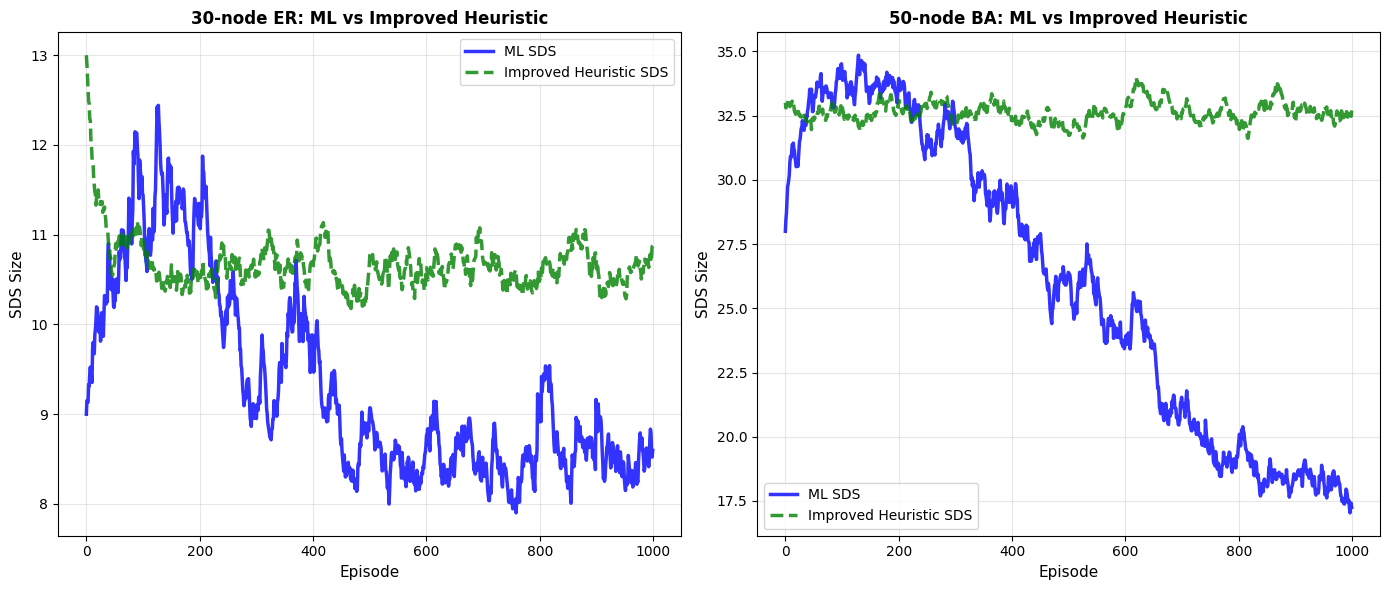


IMPROVED HEURISTIC vs ML COMPARISON SUMMARY

30-node ER:
  ML Final Average SDS Size: 8.41
  Improved Heuristic Average SDS Size: 10.57
  ML Improvement: 20.4% (better)
  ML Success Rate: 99.8%
  Heuristic Validity Rate: 99.3%

50-node BA:
  ML Final Average SDS Size: 17.95
  Improved Heuristic Average SDS Size: 32.62
  ML Improvement: 45.0% (better)
  ML Success Rate: 96.6%
  Heuristic Validity Rate: 99.9%


In [ ]:
# Improved SDS Heuristic with Theoretical Foundation
# This replaces the previous heuristic functions in your code

def networkx_to_adjacency_list(G):
    """Convert NetworkX graph to adjacency list format for heuristic algorithm"""
    n = len(G.nodes())
    adj = [[] for _ in range(n)]

    for edge in G.edges():
        u, v = edge
        adj[u].append(v)
        adj[v].append(u)

    return adj

def heuristic_sds_with_proof(graph):
    """
    Improved SDS heuristic based on theoretical construction:
    1. Find dominating set A using greedy approach
    2. Construct induced subgraph G[V \ A]
    3. Find maximal independent set B in G[V \ A]
    4. Return F = A ∪ (B \ {y}) as SDS

    This guarantees a secure dominating set by construction.
    """
    n = len(graph)
    dominated = [False] * n
    A = []

    # Step 1: Greedy dominating set construction (γ(G))
    while not all(dominated):
        best = -1
        max_cover = -1

        for u in range(n):
            if u in A:  # Skip already selected vertices
                continue

            # Count how many undominated vertices this node would cover
            cover = sum(1 for v in [u] + graph[u] if not dominated[v])

            if cover > max_cover:
                max_cover = cover
                best = u

        if best == -1:  # Safety check
            break

        A.append(best)
        # Mark this vertex and all its neighbors as dominated
        for v in [best] + graph[best]:
            dominated[v] = True

    # Step 2: Construct induced subgraph G[V \ A]
    V_minus_A = [v for v in range(n) if v not in A]

    if not V_minus_A:  # If A dominates everything, it's already SDS
        return A

    # Create mapping from original vertices to subgraph indices
    index_map = {v: i for i, v in enumerate(V_minus_A)}
    m = len(V_minus_A)
    subgraph = [[] for _ in range(m)]

    # Build adjacency list for induced subgraph G[V \ A]
    for v in V_minus_A:
        for u in graph[v]:
            if u in index_map:  # u is also in V \ A
                subgraph[index_map[v]].append(index_map[u])

    # Step 3: Find maximal independent set B in G[V \ A]
    in_B = [False] * m
    B = []

    for u in range(m):
        if not in_B[u]:
            B.append(V_minus_A[u])  # Add original vertex index
            in_B[u] = True
            # Mark all neighbors in subgraph as unavailable
            for v in subgraph[u]:
                in_B[v] = True

    # Step 4: Construct F = A ∪ (B \ {y})
    # Remove one arbitrary element from B if B is non-empty
    if B:
        B.pop()  # Remove arbitrary vertex y ∈ B

    F = A + B
    return F

def verify_sds_property(graph, sds_set):
    """
    Verify that the given set is actually a secure dominating set
    Returns (is_dominating, is_secure)
    """
    n = len(graph)
    sds_set = set(sds_set)

    # Check dominating property
    dominated = [False] * n
    for v in sds_set:
        dominated[v] = True
        for u in graph[v]:
            dominated[u] = True

    is_dominating = all(dominated)

    # Check secure property
    is_secure = True
    for u in range(n):
        if u not in sds_set:
            # Check if u can be defended by some neighbor in SDS
            can_defend = False
            for v in graph[u]:
                if v in sds_set:
                    # Check if swapping v with u maintains domination
                    temp_sds = (sds_set - {v}) | {u}
                    temp_dominated = [False] * n

                    for w in temp_sds:
                        temp_dominated[w] = True
                        for x in graph[w]:
                            temp_dominated[x] = True

                    if all(temp_dominated):
                        can_defend = True
                        break

            if not can_defend:
                is_secure = False
                break

    return is_dominating, is_secure

def sds_heuristic_improved(n, adj):
    """
    Wrapper function to maintain compatibility with existing code
    Uses the improved theoretical heuristic
    """
    return heuristic_sds_with_proof(adj)

def run_comparison_with_improved_heuristic(n_nodes, graph_type, episodes=1000):
    """
    Modified experiment function using the improved heuristic
    """

    print(f"\nRunning experiment with IMPROVED heuristic: {n_nodes}-node {graph_type} graphs")
    print("-" * 70)

    hidden_dim = 32

    # Initialize networks
    gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    q_net = GNNQNetwork(gnn, hidden_dim).to(device)
    target_gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    target_q_net = GNNQNetwork(target_gnn, hidden_dim).to(device)
    target_q_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-4)

    buffer = ReplayBuffer(capacity=2000)

    # Track results
    ml_sds_sizes = []
    heuristic_sds_sizes = []
    heuristic_valid_count = 0  # Track how many heuristic solutions are valid SDS
    episode_losses = []
    rewards_history = []
    success_episodes = 0
    epsilon = 1.0
    min_epsilon = 0.01
    decay = 0.998

    for episode in range(episodes):
        # Generate graph
        if graph_type == 'ER':
            data = generate_graph(n=n_nodes, graph_type='ER', p=0.3)
        else:  # BA
            data = generate_graph(n=n_nodes, graph_type='BA')

        num_nodes_actual = data.num_nodes

        if num_nodes_actual != n_nodes:
            continue

        data.x = torch.zeros((num_nodes_actual, 1)).to(device)
        data = data.to(device)
        state = torch.zeros(num_nodes_actual).to(device)
        adj = to_dense_adj(data.edge_index, max_num_nodes=num_nodes_actual)[0]

        if adj.shape[0] != num_nodes_actual or adj.shape[1] != num_nodes_actual:
            continue

        # Convert to adjacency list for heuristic
        G = nx.Graph()
        G.add_nodes_from(range(num_nodes_actual))
        edge_list = data.edge_index.t().cpu().numpy()
        G.add_edges_from(edge_list)
        adj_list = networkx_to_adjacency_list(G)

        # Calculate improved heuristic SDS
        heuristic_sds = heuristic_sds_with_proof(adj_list)
        heuristic_sds_sizes.append(len(heuristic_sds))

        # Verify the heuristic solution
        is_dom, is_sec = verify_sds_property(adj_list, heuristic_sds)
        if is_dom and is_sec:
            heuristic_valid_count += 1

        # ML Training episode (same as before)
        actions_taken = []
        episode_reward = 0
        episode_loss_values = []
        done = False
        steps = 0
        max_steps = n_nodes

        while not done and steps < max_steps:
            q_vals = q_net(data, state.unsqueeze(0))[0]
            action = greedy_policy(q_vals.clone(), state, epsilon)
            actions_taken.append(action)
            next_state = mask_state(state, action, data.edge_index, num_nodes_actual)
            r = reward_fn(state, action, adj, torch.ones(num_nodes_actual, device=device))

            episode_reward += r
            done = is_secure_dominating_set_complete(next_state, adj)

            if done:
                success_episodes += 1

            if (next_state >= 1).sum().item() >= num_nodes_actual * 0.8:
                done = True
                r -= 50.0

            buffer.push(Transition(state, action, r, next_state, done, data))
            state = next_state
            steps += 1

            if len(buffer) >= 8:
                loss = train_step(buffer.sample(8), q_net, target_q_net, optimizer)
                episode_loss_values.append(loss)
                soft_update(target_q_net, q_net)

        # Record results
        if episode_loss_values:
            avg_episode_loss = np.mean(episode_loss_values)
            episode_losses.append(avg_episode_loss)
        else:
            episode_losses.append(episode_losses[-1] if episode_losses else 0.0)

        ml_sds_sizes.append(len(set(actions_taken)))
        rewards_history.append(episode_reward)
        epsilon = max(min_epsilon, epsilon * decay)

        # Progress reporting
        if episode % 100 == 0:
            avg_ml_size = np.mean(ml_sds_sizes[-50:]) if len(ml_sds_sizes) >= 50 else np.mean(ml_sds_sizes)
            avg_heuristic_size = np.mean(heuristic_sds_sizes[-50:]) if len(heuristic_sds_sizes) >= 50 else np.mean(heuristic_sds_sizes)
            success_rate = success_episodes / (episode + 1) * 100
            heuristic_validity = heuristic_valid_count / (episode + 1) * 100

            print(f"Episode {episode}: ML SDS={avg_ml_size:.1f}, Improved Heuristic SDS={avg_heuristic_size:.1f}")
            print(f"  Success Rate={success_rate:.1f}%, Heuristic Validity={heuristic_validity:.1f}%, ε={epsilon:.3f}")

    return {
        'ml_sds_sizes': ml_sds_sizes,
        'heuristic_sds_sizes': heuristic_sds_sizes,
        'episode_losses': episode_losses,
        'rewards_history': rewards_history,
        'success_rate': success_episodes / episodes * 100,
        'heuristic_validity_rate': heuristic_valid_count / episodes * 100
    }

def plot_improved_sds_comparison(results_30_er, results_50_ba, episodes=1000):
    """
    Simplified plotting function focusing on SDS size comparison over episodes
    """
    plt.figure(figsize=(14, 6))

    # Plot 1: 30-node ER comparison
    plt.subplot(1, 2, 1)

    ml_smooth_30 = smooth_curve(results_30_er['ml_sds_sizes'], weight=0.95)
    heuristic_smooth_30 = smooth_curve(results_30_er['heuristic_sds_sizes'], weight=0.95)

    plt.plot(range(len(ml_smooth_30)), ml_smooth_30,
             color='blue', linewidth=2.5, label='ML SDS', alpha=0.8)
    plt.plot(range(len(heuristic_smooth_30)), heuristic_smooth_30,
             color='green', linewidth=2.5, label='Improved Heuristic SDS', alpha=0.8, linestyle='--')

    plt.xlabel("Episode", fontsize=11)
    plt.ylabel("SDS Size", fontsize=11)
    plt.title("30-node ER: ML vs Improved Heuristic", fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Plot 2: 50-node BA comparison
    plt.subplot(1, 2, 2)

    ml_smooth_50 = smooth_curve(results_50_ba['ml_sds_sizes'], weight=0.95)
    heuristic_smooth_50 = smooth_curve(results_50_ba['heuristic_sds_sizes'], weight=0.95)

    plt.plot(range(len(ml_smooth_50)), ml_smooth_50,
             color='blue', linewidth=2.5, label='ML SDS', alpha=0.8)
    plt.plot(range(len(heuristic_smooth_50)), heuristic_smooth_50,
             color='green', linewidth=2.5, label='Improved Heuristic SDS', alpha=0.8, linestyle='--')

    plt.xlabel("Episode", fontsize=11)
    plt.ylabel("SDS Size", fontsize=11)
    plt.title("50-node BA: ML vs Improved Heuristic", fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print detailed comparison
    print("\n" + "=" * 90)
    print("IMPROVED HEURISTIC vs ML COMPARISON SUMMARY")
    print("=" * 90)

    for name, results in [("30-node ER", results_30_er), ("50-node BA", results_50_ba)]:
        ml_final_avg = np.mean(results['ml_sds_sizes'][-100:])
        heur_final_avg = np.mean(results['heuristic_sds_sizes'][-100:])
        improvement = ((heur_final_avg - ml_final_avg) / heur_final_avg) * 100

        print(f"\n{name}:")
        print(f"  ML Final Average SDS Size: {ml_final_avg:.2f}")
        print(f"  Improved Heuristic Average SDS Size: {heur_final_avg:.2f}")
        print(f"  ML Improvement: {improvement:.1f}% {'(better)' if improvement > 0 else '(worse)'}")
        print(f"  ML Success Rate: {results['success_rate']:.1f}%")
        print(f"  Heuristic Validity Rate: {results['heuristic_validity_rate']:.1f}%")

def run_full_comparison_with_improved_heuristic(episodes=1000):
    """Run complete comparison with the improved theoretical heuristic"""

    print("SDS-DDQN vs IMPROVED HEURISTIC Comparison Experiment")
    print("=" * 90)
    print("Using theoretical heuristic: A ∪ (B \\ {y}) where A=dominating set, B=max independent set")
    print("=" * 90)

    # Run experiments
    results_30_er = run_comparison_with_improved_heuristic(n_nodes=30, graph_type='ER', episodes=episodes)
    results_50_ba = run_comparison_with_improved_heuristic(n_nodes=50, graph_type='BA', episodes=episodes)

    # Create enhanced plots
    plot_improved_sds_comparison(results_30_er, results_50_ba, episodes)

    return results_30_er, results_50_ba

# Usage:
# torch.manual_seed(42)
# np.random.seed(42)
# results_30_er, results_50_ba = run_full_comparison_with_improved_heuristic(episodes=1000)
torch.manual_seed(42)
np.random.seed(42)
results_30_er, results_50_ba = run_full_comparison_with_improved_heuristic(episodes=1000)

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu{cuda_version}
Looking in links: https://data.pyg.org/whl/torch-{torch.__version__}+{cu}.html
Using device: cpu
Testing Proper Interval Graph Generation...
Generated test graph with 10 nodes and 15 edges
SDS-DDQN on Proper Interval Graphs
Comparing 20-node vs 35-node proper interval graphs

Running Secure Domination experiment on 20-node proper interval graphs
----------------------------------------------------------------------

Episode 0 - Graph Analysis:
Graph Properties:
  Nodes: 20
  Edges: 81
  Density: 0.426
  Is Connected: True
  Diameter: 3
  Average Clustering: 0.834
  Interval Overlap Distribution:
    3 overlaps: 1 intervals
    4 overlaps: 1 intervals
    6 overlaps: 4 intervals
    7 overlaps: 6 intervals
    8 overlaps: 2 intervals
    9 overlaps: 1 intervals
    10 overlaps: 1 intervals
    11 overlaps: 1 intervals
    12 overlaps: 1 intervals
    13 overlaps: 1 intervals
    18 overlaps: 1

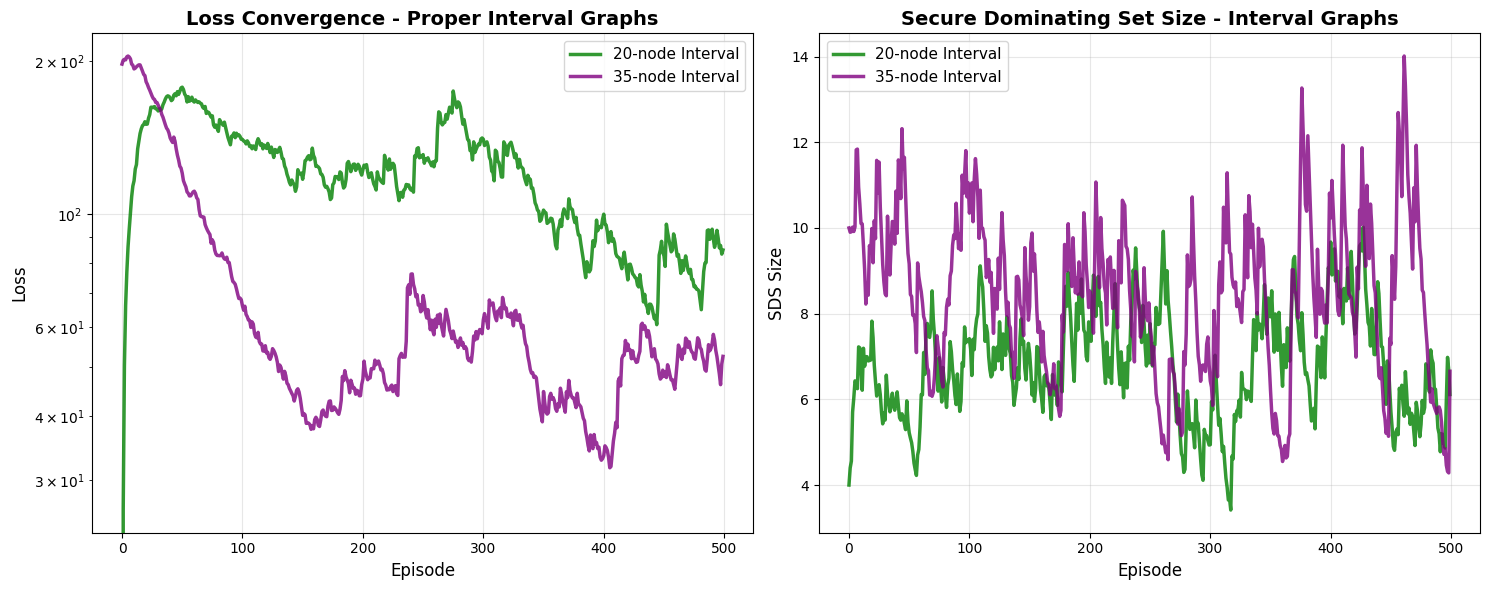


INTERVAL GRAPH COMPARISON SUMMARY
20-node Proper Interval graphs:
  - Success Rate: 86.6%
  - Average SDS Size: 5.76
  - Final Loss: 77.2869

35-node Proper Interval graphs:
  - Success Rate: 92.8%
  - Average SDS Size: 8.32
  - Final Loss: 48.8487

Interval Graph Analysis:
  - Node ratio (35/20): 1.75
  - SDS size ratio (35/20): 1.44
  - Scalability: Good


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# Install torch_geometric and its dependencies.
# Replace {CUDA_VERSION} with your CUDA version (e.g., cu116, cu117, cu118, cu121).
# If you don't have a CUDA-enabled GPU or don't want to use it, use 'cpu'.
!pip install torch_geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}+{cu}.html --extra-index-url https://download.pytorch.org/whl/cu{cuda_version}

from torch_geometric.utils import from_networkx, to_dense_adj
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from scipy import stats

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


def generate_random_intervals(n, max_coord=100):
    """Generate n random intervals [a_i, b_i] where a_i <= b_i"""
    intervals = []
    for i in range(n):
        # Generate random start and end points
        start = random.uniform(0, max_coord)
        # Ensure interval has positive length
        length = random.uniform(1, max_coord - start + 1)
        end = start + length
        intervals.append((start, end, i))  # (start, end, node_id)
    return intervals

def intervals_to_proper_interval_graph(intervals):
    """Convert intervals to proper interval graph using NetworkX"""
    G = nx.Graph()

    # Add nodes
    for _, _, node_id in intervals:
        G.add_node(node_id)

    # Add edges between intersecting intervals
    for i, (start1, end1, node1) in enumerate(intervals):
        for j, (start2, end2, node2) in enumerate(intervals):
            if i < j:  # Avoid duplicate edges
                # Two intervals intersect if max(start1, start2) < min(end1, end2)
                if max(start1, start2) < min(end1, end2):
                    G.add_edge(node1, node2)

    return G

def is_proper_interval_graph(G):
    """Check if a graph is a proper interval graph (simplified check)"""
    # A proper interval graph has no induced P4 or C4
    # This is a simplified check - full verification is more complex

    # Check for induced P4 (path of length 3)
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            for k in range(j+1, len(nodes)):
                for l in range(k+1, len(nodes)):
                    subgraph = G.subgraph([nodes[i], nodes[j], nodes[k], nodes[l]])
                    if subgraph.number_of_edges() == 3:
                        # Check if it forms a P4
                        degrees = [subgraph.degree(n) for n in subgraph.nodes()]
                        if degrees.count(1) == 2 and degrees.count(2) == 2:
                            return False

    return True

def generate_proper_interval_graph(n=20, max_attempts=100):
    """Generate a proper interval graph with n nodes"""
    for attempt in range(max_attempts):
        intervals = generate_random_intervals(n, max_coord=100)
        G = intervals_to_proper_interval_graph(intervals)

        # Ensure we have the right number of nodes
        if G.number_of_nodes() == n:
            # Add simple node features
            for node in G.nodes():
                G.nodes[node]['x'] = [0.0]  # Simple constant feature

            return G, intervals

    # Fallback: create a simple proper interval graph
    print(f"Warning: Could not generate proper interval graph with {n} nodes, creating fallback")
    G = nx.path_graph(n)  # Path graphs are proper interval graphs
    intervals = [(i, i+1, i) for i in range(n)]

    for i, node in enumerate(G.nodes()):
        G.nodes[node]['x'] = [0.0]

    return G, intervals

def analyze_interval_graph_properties(G, intervals):
    """Analyze properties of the generated interval graph"""
    print(f"Graph Properties:")
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.3f}")
    print(f"  Is Connected: {nx.is_connected(G)}")

    if nx.is_connected(G):
        print(f"  Diameter: {nx.diameter(G)}")
        print(f"  Average Clustering: {nx.average_clustering(G):.3f}")

    # Analyze interval overlaps
    overlap_counts = defaultdict(int)
    for i, (start1, end1, _) in enumerate(intervals):
        count = 0
        for j, (start2, end2, _) in enumerate(intervals):
            if i != j and max(start1, start2) < min(end1, end2):
                count += 1
        overlap_counts[count] += 1

    print(f"  Interval Overlap Distribution:")
    for overlap_count, frequency in sorted(overlap_counts.items()):
        print(f"    {overlap_count} overlaps: {frequency} intervals")


class MPNNLayer(MessagePassing):
    """Message Passing Neural Network Layer for graph convolution"""

    def __init__(self, in_dim, edge_dim, hidden_dim):
        super(MPNNLayer, self).__init__(aggr='add')
        self.theta1 = nn.Linear(in_dim * 2 + edge_dim, hidden_dim)
        self.theta2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        """Compute messages between connected nodes"""
        m = torch.cat([x_i, x_j, edge_attr], dim=1)
        m = F.relu(self.theta1(m))
        m = F.relu(self.theta2(m))
        return m

class VertexEdgeEmbedding(nn.Module):
    """Creates embeddings for vertices considering edge information"""

    def __init__(self, node_feat_dim, adj_dim, hidden_dim):
        super(VertexEdgeEmbedding, self).__init__()
        self.f_theta = nn.Linear(node_feat_dim + adj_dim, hidden_dim)
        self.edge_theta = nn.Linear(hidden_dim + adj_dim, hidden_dim)

    def forward(self, node_feat, adj):

        A_norm = adj / (adj.sum(dim=-1, keepdim=True) + 1e-6)


        vf_A = torch.cat([node_feat, adj], dim=1)
        f = F.relu(self.f_theta(vf_A))


        combined = torch.cat([f, A_norm], dim=1)
        e = F.relu(self.edge_theta(combined))
        return e

class FullMPNN(nn.Module):
    """Complete Message Passing Neural Network"""

    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_nodes, num_layers=3):
        super(FullMPNN, self).__init__()
        self.vertex_embedder = VertexEdgeEmbedding(node_feat_dim, num_nodes, hidden_dim)
        self.gnn_layers = nn.ModuleList([
            MPNNLayer(node_feat_dim if i == 0 else hidden_dim, hidden_dim, hidden_dim)
            for i in range(num_layers)
        ])

    def forward(self, x, edge_index, adj):
        # Create edge embeddings
        edge_attr_node_level = self.vertex_embedder(x, adj)
        num_edges = edge_index.size(1)
        edge_attr_per_edge = edge_attr_node_level.new_zeros((num_edges, edge_attr_node_level.size(-1)))

        # Apply GNN layers
        x = self.gnn_layers[0](x, edge_index, edge_attr_per_edge)
        for i in range(1, len(self.gnn_layers)):
            x = self.gnn_layers[i](x, edge_index, edge_attr_per_edge)
        return x

class GNNQNetwork(nn.Module):
    """Q-Network combining GNN with Q-value output"""

    def __init__(self, gnn, hidden_dim):
        super(GNNQNetwork, self).__init__()
        self.gnn = gnn
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, data, state_batch):
        adj = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0]
        x_embed = self.gnn(data.x, data.edge_index, adj)
        q_values = self.output_layer(x_embed).squeeze(-1)
        return q_values.unsqueeze(0)


def get_neighbors(node, adj_matrix):
    """Get neighbors of a node from adjacency matrix"""
    return (adj_matrix[node] > 0).nonzero(as_tuple=True)[0]

def is_securely_dominated(node, dominating_set, adj_matrix):
    """Check if a node is securely dominated by the dominating set."""
    # Convert state tensor to set for easier operations
    if isinstance(dominating_set, torch.Tensor):
        dom_set = set((dominating_set >= 1).nonzero(as_tuple=True)[0].cpu().numpy())
    else:
        dom_set = set(dominating_set)

    # If the node itself is in the dominating set, it's securely dominated
    if node in dom_set:
        return True

    # Check if any dominating neighbor can securely dominate this node
    neighbors = get_neighbors(node, adj_matrix)

    for neighbor in neighbors:
        if neighbor.item() in dom_set:  # This neighbor is in the dominating set
            # For secure domination, the dominating neighbor must have at least
            # one other neighbor (besides the current node being checked)
            neighbor_neighbors = get_neighbors(neighbor, adj_matrix)

            # Count other neighbors (excluding the node being dominated)
            other_neighbors = [n for n in neighbor_neighbors if n.item() != node]

            # The dominating node can securely dominate if it has other connections
            if len(other_neighbors) > 0:
                return True

    return False

def is_secure_dominating_set_complete(state, adj_matrix):
    """Check if the current state forms a complete secure dominating set."""
    num_nodes = adj_matrix.shape[0]

    for node in range(num_nodes):
        if not is_securely_dominated(node, state, adj_matrix):
            return False

    return True

def sds_reward_function(state, action, adj_matrix, weight_vector=None):
    """Improved reward function for secure dominating set learning."""
    num_nodes = adj_matrix.shape[0]

    # Create new state after action
    new_state = state.clone()
    new_state[action] = 1

    # Check if action creates redundancy (node already selected)
    if state[action] == 1:  # Already selected
        return -10.0

    # Calculate domination coverage before and after
    dom_before = sum(1 for i in range(num_nodes) if is_securely_dominated(i, state, adj_matrix))
    dom_after = sum(1 for i in range(num_nodes) if is_securely_dominated(i, new_state, adj_matrix))

    coverage_increase = dom_after - dom_before

    # Base reward for coverage increase
    reward = coverage_increase * 5.0

    # Check if we've completed a secure dominating set
    if is_secure_dominating_set_complete(new_state, adj_matrix):
        set_size = (new_state >= 1).sum().item()
        # Reward inversely proportional to set size (encourage smaller sets)
        size_bonus = max(0, 50 - set_size * 2)
        reward += 100.0 + size_bonus

    # Penalty for large sets (encourage efficiency)
    current_size = (new_state >= 1).sum().item()
    if current_size > num_nodes * 0.7:  # If more than 70% of nodes selected
        reward -= 20.0

    # Small penalty to encourage exploration of smaller solutions
    reward -= 0.5

    return reward

def mask_state(state, action, edge_index, num_nodes):
    """Update state by selecting a node for the dominating set"""
    new_state = state.clone()
    new_state[action] = 1
    return new_state

def reward_fn(state, action, adj_matrix, weight_vector):
    """Wrapper for reward function"""
    return sds_reward_function(state, action, adj_matrix, weight_vector)

def greedy_policy(q_values, state, epsilon=0.1):
    """Epsilon-greedy action selection"""
    candidates = (state < 1).nonzero(as_tuple=True)[0]
    if len(candidates) == 0:
        return torch.randint(0, len(state), (1,)).item()

    if np.random.rand() < epsilon:
        return np.random.choice(candidates.cpu().numpy()).item()

    q_values[~(state < 1)] = -float('inf')
    return torch.argmax(q_values).item()

class Transition:
    """Store transition information for replay buffer"""
    def __init__(self, state, action, reward, next_state, done, data):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.done = done
        self.data = data

class ReplayBuffer:
    """Experience replay buffer for DQN"""
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []

    def push(self, transition):
        self.buffer.append(transition)
        self.buffer = self.buffer[-self.capacity:]

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        return [self.buffer[i] for i in indices]

    def __len__(self):
        return len(self.buffer)

def train_step(batch, q_net, target_q_net, optimizer, gamma=0.95):
    """Single training step for DQN"""
    q_values, target_q_values = [], []

    for transition in batch:
        # Current Q-value
        q_vals = q_net(transition.data, transition.state.unsqueeze(0))[0]
        q_val = q_vals[transition.action]

        # Target Q-value
        with torch.no_grad():
            next_q_vals = target_q_net(transition.data, transition.next_state.unsqueeze(0))[0]
            if next_q_vals.numel() == 0:
                best_next_q = torch.tensor(0.0, device=next_q_vals.device)
            else:
                best_next_q = torch.max(next_q_vals)

            reward_tensor = torch.tensor(transition.reward, device=q_val.device)
            zero_tensor = torch.tensor(0.0, device=q_val.device)

            target_val = reward_tensor + (zero_tensor if transition.done else
                        gamma * best_next_q)

        q_values.append(q_val)
        target_q_values.append(torch.clamp(target_val.detach(), -30.0, 30.0))

    if not q_values:
        return 0.0

    loss = F.mse_loss(torch.stack(q_values), torch.stack(target_q_values))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
    optimizer.step()
    return loss.item()

def soft_update(target_net, source_net, tau=0.005):
    """Soft update of target network parameters"""
    with torch.no_grad():
        for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
            target_param.data.mul_(1.0 - tau).add_(tau * source_param.data)

def generate_interval_graph_data(n=20):
    """Generate proper interval graph data for training"""
    G, intervals = generate_proper_interval_graph(n)

    # Handle empty graph case
    if len(G) == 0 and n > 0:
        print(f"Warning: Generated empty graph for n={n}.")
        G = nx.Graph()
        for i in range(n):
            G.add_node(i)
            G.nodes[i]['x'] = [0.0]  # Simple node feature

    # Add simple node features (just a constant feature)
    for node in G.nodes():
        if 'x' not in G.nodes[node]:
            G.nodes[node]['x'] = [0.0]

    data = from_networkx(G)
    data.num_nodes = len(G)

    return data, intervals

def smooth_curve(values, weight=0.9):
    """Smooth learning curves for visualization"""
    if not values:
        return []
    smoothed, last = [], values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def run_interval_graph_experiment(n_nodes, episodes=300):
    """Run experiment on proper interval graphs"""

    print(f"\nRunning Secure Domination experiment on {n_nodes}-node proper interval graphs")
    print("-" * 70)

    hidden_dim = 32  # Standard hidden dimension

    # Initialize networks with standard architecture
    gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)  # 1 feature: constant
    q_net = GNNQNetwork(gnn, hidden_dim).to(device)
    target_gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    target_q_net = GNNQNetwork(target_gnn, hidden_dim).to(device)
    target_q_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-4)  # Standard learning rate

    buffer = ReplayBuffer(capacity=1000)

    episode_losses = []
    sds_sizes, rewards_history = [], []
    success_episodes = 0
    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.995

    for episode in range(episodes):
        # Generate proper interval graph
        data, intervals = generate_interval_graph_data(n=n_nodes)

        num_nodes_actual = data.num_nodes

        if num_nodes_actual != n_nodes:
            continue

        data.x = torch.zeros((num_nodes_actual, 1)).to(device)  # Simple node features
        data = data.to(device)
        state = torch.zeros(num_nodes_actual).to(device)
        adj = to_dense_adj(data.edge_index, max_num_nodes=num_nodes_actual)[0]

        if adj.shape[0] != num_nodes_actual or adj.shape[1] != num_nodes_actual:
            continue

        # Show graph properties for first few episodes
        if episode < 3:
            print(f"\nEpisode {episode} - Graph Analysis:")
            analyze_interval_graph_properties(nx.from_numpy_array(adj.cpu().numpy()), intervals)

        actions_taken = []
        episode_reward = 0
        episode_loss_values = []
        done = False
        steps = 0
        max_steps = n_nodes

        while not done and steps < max_steps:
            q_vals = q_net(data, state.unsqueeze(0))[0]
            action = greedy_policy(q_vals.clone(), state, epsilon)
            actions_taken.append(action)
            next_state = mask_state(state, action, data.edge_index, num_nodes_actual)
            r = reward_fn(state, action, adj, torch.ones(num_nodes_actual, device=device))

            episode_reward += r

            # Check if we have a complete secure dominating set
            done = is_secure_dominating_set_complete(next_state, adj)

            if done:
                success_episodes += 1

            # Safety check: if we've selected too many nodes, force termination
            if (next_state >= 1).sum().item() >= num_nodes_actual * 0.8:
                done = True
                r -= 50.0  # Large penalty for inefficient solution

            buffer.push(Transition(state, action, r, next_state, done, data))
            state = next_state
            steps += 1

            # Training step
            if len(buffer) >= 8:
                loss = train_step(buffer.sample(8), q_net, target_q_net, optimizer)
                episode_loss_values.append(loss)
                soft_update(target_q_net, q_net)

        # Record average loss for this episode
        if episode_loss_values:
            avg_episode_loss = np.mean(episode_loss_values)
            episode_losses.append(avg_episode_loss)
        else:
            episode_losses.append(episode_losses[-1] if episode_losses else 0.0)

        sds_sizes.append(len(set(actions_taken)))
        rewards_history.append(episode_reward)
        epsilon = max(min_epsilon, epsilon * decay)

        if episode % 50 == 0:
            avg_loss = np.mean(episode_losses[-50:]) if len(episode_losses) >= 50 else np.mean(episode_losses) if episode_losses else 0
            avg_sds_size = np.mean(sds_sizes[-25:]) if len(sds_sizes) >= 25 else np.mean(sds_sizes)
            avg_reward = np.mean(rewards_history[-25:]) if len(rewards_history) >= 25 else np.mean(rewards_history)
            success_rate = success_episodes / (episode + 1) * 100

            print(f"Episode {episode}: Loss={avg_loss:.4f}, SDS Size={avg_sds_size:.1f}, "
                  f"Reward={avg_reward:.1f}, Success Rate={success_rate:.1f}%")

    # Final statistics
    final_success_rate = success_episodes / episodes * 100
    avg_final_size = np.mean(sds_sizes[-50:]) if len(sds_sizes) >= 50 else np.mean(sds_sizes)

    print(f"\nFinal Results for {n_nodes}-node Proper Interval Graphs:")
    print(f"  Success Rate: {final_success_rate:.1f}%")
    print(f"  Average SDS Size: {avg_final_size:.2f}")
    print(f"  Episodes with Valid SDS: {success_episodes}/{episodes}")

    return {
        'episode_losses': episode_losses,
        'sds_sizes': sds_sizes,
        'rewards_history': rewards_history,
        'success_rate': final_success_rate,
        'avg_sds_size': avg_final_size
    }

def run_interval_graph_comparison(episodes=400):
    """Run comparison between different sizes of proper interval graphs"""

    print("SDS-DDQN on Proper Interval Graphs")
    print("=" * 70)
    print("Comparing 20-node vs 35-node proper interval graphs")
    print("=" * 70)

    # Run both experiments
    results_20 = run_interval_graph_experiment(n_nodes=20, episodes=episodes)
    results_35 = run_interval_graph_experiment(n_nodes=35, episodes=episodes)

    # Create comparison plots
    plt.figure(figsize=(15, 6))

    # Plot 1: Loss Convergence Comparison
    plt.subplot(1, 2, 1)

    if results_20['episode_losses']:
        smoothed_loss_20 = smooth_curve(results_20['episode_losses'], weight=0.95)
        plt.plot(range(len(smoothed_loss_20)), smoothed_loss_20,
                color='green', linewidth=2.5, label='20-node Interval', alpha=0.8)

    if results_35['episode_losses']:
        smoothed_loss_35 = smooth_curve(results_35['episode_losses'], weight=0.95)
        plt.plot(range(len(smoothed_loss_35)), smoothed_loss_35,
                color='purple', linewidth=2.5, label='35-node Interval', alpha=0.8)

    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.title("Loss Convergence - Proper Interval Graphs", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    # Plot 2: SDS Size Comparison
    plt.subplot(1, 2, 2)

    smoothed_sizes_20 = smooth_curve(results_20['sds_sizes'], weight=0.9)
    smoothed_sizes_35 = smooth_curve(results_35['sds_sizes'], weight=0.9)

    plt.plot(smoothed_sizes_20, color='green', linewidth=2.5,
            label='20-node Interval', alpha=0.8)
    plt.plot(smoothed_sizes_35, color='purple', linewidth=2.5,
            label='35-node Interval', alpha=0.8)

    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("SDS Size", fontsize=12)
    plt.title("Secure Dominating Set Size - Interval Graphs", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print comparison summary
    print("\n" + "=" * 70)
    print("INTERVAL GRAPH COMPARISON SUMMARY")
    print("=" * 70)
    print(f"20-node Proper Interval graphs:")
    print(f"  - Success Rate: {results_20['success_rate']:.1f}%")
    print(f"  - Average SDS Size: {results_20['avg_sds_size']:.2f}")
    print(f"  - Final Loss: {np.mean(results_20['episode_losses'][-10:]) if results_20['episode_losses'] else 'N/A':.4f}")

    print(f"\n35-node Proper Interval graphs:")
    print(f"  - Success Rate: {results_35['success_rate']:.1f}%")
    print(f"  - Average SDS Size: {results_35['avg_sds_size']:.2f}")
    print(f"  - Final Loss: {np.mean(results_35['episode_losses'][-10:]) if results_35['episode_losses'] else 'N/A':.4f}")

    # Analysis
    size_ratio = results_35['avg_sds_size'] / results_20['avg_sds_size'] if results_20['avg_sds_size'] > 0 else float('inf')
    node_ratio = 35 / 20

    print(f"\nInterval Graph Analysis:")
    print(f"  - Node ratio (35/20): {node_ratio:.2f}")
    print(f"  - SDS size ratio (35/20): {size_ratio:.2f}")
    print(f"  - Scalability: {'Good' if size_ratio < node_ratio * 1.2 else 'Moderate' if size_ratio < node_ratio * 1.5 else 'Poor'}")

# ================================
# Run the Interval Graph Experiment
# ================================

if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # Test interval graph generation first
    print("Testing Proper Interval Graph Generation...")
    test_graph, test_intervals = generate_proper_interval_graph(10)
    print(f"Generated test graph with {test_graph.number_of_nodes()} nodes and {test_graph.number_of_edges()} edges")

    # Run the comparison experiment
    run_interval_graph_comparison(episodes=500)

Using device: cpu
Starting Enhanced Single Graph SDS Comparison: ML vs Optimal Algorithm

SINGLE GRAPH EXPERIMENT: 25-node Proper Interval Graph
Generated 25-node graph with 99 edges
Optimal SDS size: 3
Training ML model on 25-node graph for 1000 episodes...
  Episode 0/1000, ML SDS size: 14
  Episode 200/1000, ML SDS size: 14
  Episode 400/1000, ML SDS size: 5
  Episode 600/1000, ML SDS size: 4
  Episode 800/1000, ML SDS size: 4

SINGLE GRAPH EXPERIMENT: 75-node Proper Interval Graph
Generated 75-node graph with 1356 edges
Optimal SDS size: 3
Training ML model on 75-node graph for 1000 episodes...
  Episode 0/1000, ML SDS size: 18
  Episode 200/1000, ML SDS size: 6
  Episode 400/1000, ML SDS size: 4
  Episode 600/1000, ML SDS size: 4
  Episode 800/1000, ML SDS size: 6

FINAL RESULTS

25-Node Graph:
  Optimal SDS size: 3
  ML SDS size - Mean: 6.52, Std: 3.96
  ML SDS size - Min: 3, Max: 20
  Performance Gap: 3.52

75-Node Graph:
  Optimal SDS size: 3
  ML SDS size - Mean: 6.33, Std: 4.

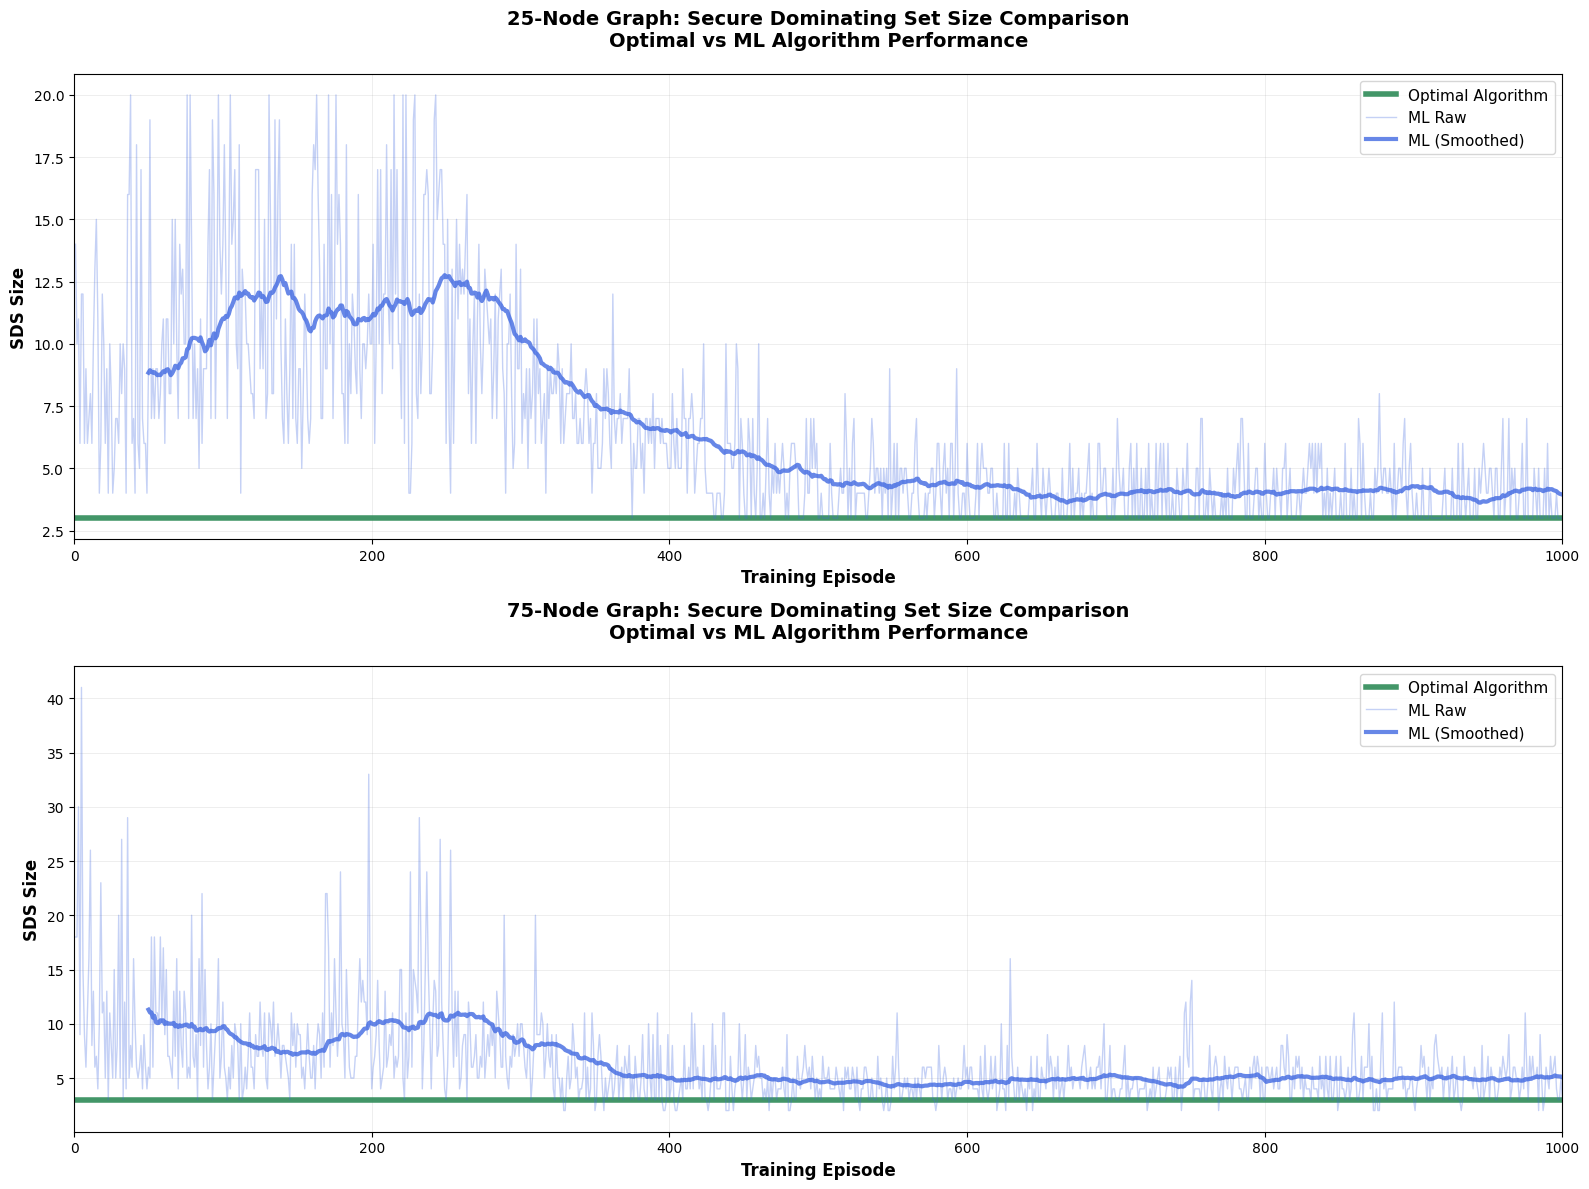

Enhanced experiment completed!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# Uncomment the line below if running in Colab
# !pip install torch_geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}+{cu}.html --extra-index-url https://download.pytorch.org/whl/cu{cuda_version}

from torch_geometric.utils import from_networkx, to_dense_adj
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from scipy import stats

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def compute_maxN(intervals):
    """Compute maxN for each interval (rightmost neighbor index)"""
    n = len(intervals)
    maxN = [0] * n
    p = 1
    for i in range(n):
        if i >= 1:
            maxN[i] = maxN[i - 1]
        while p < n and intervals[i][1] >= intervals[p][0]:
            maxN[i] = p
            p += 1
    return maxN

def calcSDS_PI(intervals):
    """
    intervals: list of [li, ri] with sorted left and right endpoints
    Returns a minimum secure dominating set (SDS) as list of interval indices (0-based)
    """
    n = len(intervals)
    if n == 0:
        return []

    maxN = compute_maxN(intervals)

    # Initialize
    y = [0]
    w = [0]
    x = [maxN[0]]
    t = [maxN[0]]
    z = [maxN[x[0]]]
    i = 0
    SDS = [x[0]]

    while t[i] < n - 1:
        i += 1
        y.append(t[i - 1] + 1)

        if t[i - 1] == z[i - 1]:
            w.append(y[i])
            x.append(maxN[y[i]])
            t.append(maxN[y[i]])
            z.append(maxN[x[i]])
        else:
            if y[i - 1] < w[i - 1] and x[i - 1] < t[i - 1]:
                y_prime = maxN[y[i - 1]]
                x.append(maxN[min(y_prime + 1, n - 1)])
            else:
                x.append(maxN[y[i]])

            z_iprev_plus = min(z[i - 1] + 1, n - 1)
            w.append(min(z_iprev_plus, x[i]))
            t.append(maxN[w[i]])
            z.append(maxN[x[i]])

        SDS.append(x[i])

        if y[i] < w[i] and x[i] < n - 1 and maxN[y[i]] < n - 1:
            SDS.append(n - 1)
            break

    return sorted(set(SDS))

def generate_random_intervals(n, max_coord=100):
    """Generate n random intervals [a_i, b_i] where a_i <= b_i"""
    intervals = []
    for i in range(n):
        start = random.uniform(0, max_coord)
        length = random.uniform(1, max_coord - start + 1)
        end = start + length
        intervals.append((start, end, i))
    return intervals

def intervals_to_proper_interval_graph(intervals):
    """Convert intervals to proper interval graph using NetworkX"""
    G = nx.Graph()

    for _, _, node_id in intervals:
        G.add_node(node_id)

    for i, (start1, end1, node1) in enumerate(intervals):
        for j, (start2, end2, node2) in enumerate(intervals):
            if i < j:
                if max(start1, start2) < min(end1, end2):
                    G.add_edge(node1, node2)

    return G

def generate_proper_interval_graph(n=20, max_attempts=100):
    """Generate a proper interval graph with n nodes"""
    for attempt in range(max_attempts):
        intervals = generate_random_intervals(n, max_coord=100)
        G = intervals_to_proper_interval_graph(intervals)

        if G.number_of_nodes() == n:
            for node in G.nodes():
                G.nodes[node]['x'] = [0.0]
            return G, intervals

    print(f"Warning: Could not generate proper interval graph with {n} nodes, creating fallback")
    G = nx.path_graph(n)
    intervals = [(i, i+1, i) for i in range(n)]

    for i, node in enumerate(G.nodes()):
        G.nodes[node]['x'] = [0.0]

    return G, intervals

def sort_intervals_for_algorithm(intervals):
    """Sort intervals by left endpoint for the optimal algorithm"""
    # Convert to format expected by algorithm: [(left, right), ...]
    sorted_intervals = sorted([(start, end) for start, end, _ in intervals])
    return sorted_intervals

class MPNNLayer(MessagePassing):
    def __init__(self, in_dim, edge_dim, hidden_dim):
        super(MPNNLayer, self).__init__(aggr='add')
        self.theta1 = nn.Linear(in_dim * 2 + edge_dim, hidden_dim)
        self.theta2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        m = torch.cat([x_i, x_j, edge_attr], dim=1)
        m = F.relu(self.theta1(m))
        m = F.relu(self.theta2(m))
        return m

class VertexEdgeEmbedding(nn.Module):
    def __init__(self, node_feat_dim, adj_dim, hidden_dim):
        super(VertexEdgeEmbedding, self).__init__()
        self.f_theta = nn.Linear(node_feat_dim + adj_dim, hidden_dim)
        self.edge_theta = nn.Linear(hidden_dim + adj_dim, hidden_dim)

    def forward(self, node_feat, adj):
        A_norm = adj / (adj.sum(dim=-1, keepdim=True) + 1e-6)
        vf_A = torch.cat([node_feat, adj], dim=1)
        f = F.relu(self.f_theta(vf_A))
        combined = torch.cat([f, A_norm], dim=1)
        e = F.relu(self.edge_theta(combined))
        return e

class FullMPNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_nodes, num_layers=3):
        super(FullMPNN, self).__init__()
        self.vertex_embedder = VertexEdgeEmbedding(node_feat_dim, num_nodes, hidden_dim)
        self.gnn_layers = nn.ModuleList([
            MPNNLayer(node_feat_dim if i == 0 else hidden_dim, hidden_dim, hidden_dim)
            for i in range(num_layers)
        ])

    def forward(self, x, edge_index, adj):
        edge_attr_node_level = self.vertex_embedder(x, adj)
        num_edges = edge_index.size(1)
        edge_attr_per_edge = edge_attr_node_level.new_zeros((num_edges, edge_attr_node_level.size(-1)))

        x = self.gnn_layers[0](x, edge_index, edge_attr_per_edge)
        for i in range(1, len(self.gnn_layers)):
            x = self.gnn_layers[i](x, edge_index, edge_attr_per_edge)
        return x

class GNNQNetwork(nn.Module):
    def __init__(self, gnn, hidden_dim):
        super(GNNQNetwork, self).__init__()
        self.gnn = gnn
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, data, state_batch):
        adj = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0]
        x_embed = self.gnn(data.x, data.edge_index, adj)
        q_values = self.output_layer(x_embed).squeeze(-1)
        return q_values.unsqueeze(0)

def get_neighbors(node, adj_matrix):
    """Get neighbors of a node from adjacency matrix"""
    return (adj_matrix[node] > 0).nonzero(as_tuple=True)[0]

def is_securely_dominated(node, dominating_set, adj_matrix):
    """Check if a node is securely dominated by the dominating set."""
    if isinstance(dominating_set, torch.Tensor):
        dom_set = set((dominating_set >= 1).nonzero(as_tuple=True)[0].cpu().numpy())
    else:
        dom_set = set(dominating_set)

    if node in dom_set:
        return True

    neighbors = get_neighbors(node, adj_matrix)
    for neighbor in neighbors:
        if neighbor.item() in dom_set:
            neighbor_neighbors = get_neighbors(neighbor, adj_matrix)
            other_neighbors = [n for n in neighbor_neighbors if n.item() != node]
            if len(other_neighbors) > 0:
                return True

    return False

def is_secure_dominating_set_complete(state, adj_matrix):
    """Check if the current state forms a complete secure dominating set."""
    num_nodes = adj_matrix.shape[0]
    for node in range(num_nodes):
        if not is_securely_dominated(node, state, adj_matrix):
            return False
    return True

def sds_reward_function(state, action, adj_matrix, weight_vector=None):
    """Reward function for secure dominating set learning."""
    num_nodes = adj_matrix.shape[0]
    new_state = state.clone()
    new_state[action] = 1

    if state[action] == 1:
        return -10.0

    dom_before = sum(1 for i in range(num_nodes) if is_securely_dominated(i, state, adj_matrix))
    dom_after = sum(1 for i in range(num_nodes) if is_securely_dominated(i, new_state, adj_matrix))
    coverage_increase = dom_after - dom_before
    reward = coverage_increase * 5.0

    if is_secure_dominating_set_complete(new_state, adj_matrix):
        set_size = (new_state >= 1).sum().item()
        size_bonus = max(0, 50 - set_size * 2)
        reward += 100.0 + size_bonus

    current_size = (new_state >= 1).sum().item()
    if current_size > num_nodes * 0.7:
        reward -= 20.0

    reward -= 0.5
    return reward

def mask_state(state, action, edge_index, num_nodes):
    """Update state by selecting a node for the dominating set"""
    new_state = state.clone()
    new_state[action] = 1
    return new_state

def reward_fn(state, action, adj_matrix, weight_vector):
    """Wrapper for reward function"""
    return sds_reward_function(state, action, adj_matrix, weight_vector)

def greedy_policy(q_values, state, epsilon=0.1):
    """Epsilon-greedy action selection"""
    candidates = (state < 1).nonzero(as_tuple=True)[0]
    if len(candidates) == 0:
        return torch.randint(0, len(state), (1,)).item()

    if np.random.rand() < epsilon:
        return np.random.choice(candidates.cpu().numpy()).item()

    q_values[~(state < 1)] = -float('inf')
    return torch.argmax(q_values).item()

class Transition:
    def __init__(self, state, action, reward, next_state, done, data):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.done = done
        self.data = data

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []

    def push(self, transition):
        self.buffer.append(transition)
        self.buffer = self.buffer[-self.capacity:]

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        return [self.buffer[i] for i in indices]

    def __len__(self):
        return len(self.buffer)

def train_step(batch, q_net, target_q_net, optimizer, gamma=0.95):
    """Single training step for DQN"""
    q_values, target_q_values = [], []

    for transition in batch:
        q_vals = q_net(transition.data, transition.state.unsqueeze(0))[0]
        q_val = q_vals[transition.action]

        with torch.no_grad():
            next_q_vals = target_q_net(transition.data, transition.next_state.unsqueeze(0))[0]
            if next_q_vals.numel() == 0:
                best_next_q = torch.tensor(0.0, device=next_q_vals.device)
            else:
                best_next_q = torch.max(next_q_vals)

            reward_tensor = torch.tensor(transition.reward, device=q_val.device)
            zero_tensor = torch.tensor(0.0, device=q_val.device)
            target_val = reward_tensor + (zero_tensor if transition.done else gamma * best_next_q)

        q_values.append(q_val)
        target_q_values.append(torch.clamp(target_val.detach(), -30.0, 30.0))

    if not q_values:
        return 0.0

    loss = F.mse_loss(torch.stack(q_values), torch.stack(target_q_values))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
    optimizer.step()
    return loss.item()

def soft_update(target_net, source_net, tau=0.005):
    """Soft update of target network parameters"""
    with torch.no_grad():
        for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
            target_param.data.mul_(1.0 - tau).add_(tau * source_param.data)

def train_ml_model(data, intervals, episodes=1000):
    """Train ML model on a specific graph for given episodes"""
    n_nodes = data.num_nodes
    print(f"Training ML model on {n_nodes}-node graph for {episodes} episodes...")

    hidden_dim = 32
    gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    q_net = GNNQNetwork(gnn, hidden_dim).to(device)
    target_gnn = FullMPNN(1, hidden_dim, hidden_dim, num_nodes=n_nodes)
    target_q_net = GNNQNetwork(target_gnn, hidden_dim).to(device)
    target_q_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-4)

    buffer = ReplayBuffer(capacity=1000)
    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.995

    ml_sizes = []

    for episode in range(episodes):
        data.x = torch.zeros((n_nodes, 1)).to(device)
        data_gpu = data.to(device)
        state = torch.zeros(n_nodes).to(device)
        adj = to_dense_adj(data_gpu.edge_index, max_num_nodes=n_nodes)[0]

        done = False
        steps = 0
        max_steps = n_nodes

        while not done and steps < max_steps:
            q_vals = q_net(data_gpu, state.unsqueeze(0))[0]
            action = greedy_policy(q_vals.clone(), state, epsilon)
            next_state = mask_state(state, action, data_gpu.edge_index, n_nodes)
            r = reward_fn(state, action, adj, torch.ones(n_nodes, device=device))

            done = is_secure_dominating_set_complete(next_state, adj)
            if (next_state >= 1).sum().item() >= n_nodes * 0.8:
                done = True
                r -= 50.0

            buffer.push(Transition(state, action, r, next_state, done, data_gpu))
            state = next_state
            steps += 1

            if len(buffer) >= 8:
                loss = train_step(buffer.sample(8), q_net, target_q_net, optimizer)
                soft_update(target_q_net, q_net)

        # Record ML SDS size for this episode
        ml_sds_size = (state >= 1).sum().item()
        ml_sizes.append(ml_sds_size)

        epsilon = max(min_epsilon, epsilon * decay)

        if episode % 200 == 0:
            print(f"  Episode {episode}/{episodes}, ML SDS size: {ml_sds_size}")

    return q_net, ml_sizes

def run_single_graph_experiment(n_nodes, episodes=1000):
    """Run experiment on a single graph for both optimal and ML algorithms"""
    print(f"\n{'='*60}")
    print(f"SINGLE GRAPH EXPERIMENT: {n_nodes}-node Proper Interval Graph")
    print(f"{'='*60}")

    # Generate single test graph
    G, intervals = generate_proper_interval_graph(n_nodes)
    print(f"Generated {n_nodes}-node graph with {G.number_of_edges()} edges")

    # Get optimal SDS (same for all episodes)
    sorted_intervals = sort_intervals_for_algorithm(intervals)
    optimal_sds = calcSDS_PI(sorted_intervals)
    optimal_size = len(optimal_sds)
    print(f"Optimal SDS size: {optimal_size}")

    # Train ML model and get ML sizes for each episode
    data = from_networkx(G)
    data.num_nodes = len(G)
    trained_model, ml_sizes = train_ml_model(data, intervals, episodes)

    # Create optimal sizes array (constant)
    optimal_sizes = [optimal_size] * episodes

    return {
        'optimal_sizes': optimal_sizes,
        'ml_sizes': ml_sizes,
        'n_nodes': n_nodes,
        'episodes': episodes
    }

def plot_enhanced_results(results_25, results_75):
    """Enhanced visualization with clearer differentiation between optimal and ML"""
    # Set up the plot style for better clarity
    plt.style.use('default')
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # Enhanced colors and styling
    optimal_color = '#2E8B57'  # Sea Green
    ml_color = '#4169E1'       # Royal Blue

    # 25-node graph results
    episodes_25 = range(1, results_25['episodes'] + 1)

    # Apply smoothing to ML results for clearer trend visualization
    window_size = 50
    ml_smoothed_25 = np.convolve(results_25['ml_sizes'], np.ones(window_size)/window_size, mode='valid')
    episodes_smoothed_25 = range(window_size, results_25['episodes'] + 1)

    axes[0].plot(episodes_25, results_25['optimal_sizes'],
                color=optimal_color, linewidth=4, label='Optimal Algorithm', alpha=0.9)
    axes[0].plot(episodes_25, results_25['ml_sizes'],
                color=ml_color, linewidth=1, alpha=0.3, label='ML Raw')
    axes[0].plot(episodes_smoothed_25, ml_smoothed_25,
                color=ml_color, linewidth=3, label='ML (Smoothed)', alpha=0.8)


    axes[0].set_xlabel('Training Episode', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('SDS Size', fontsize=12, fontweight='bold')
    axes[0].set_title('25-Node Graph: Secure Dominating Set Size Comparison\nOptimal vs ML Algorithm Performance',
                     fontsize=14, fontweight='bold', pad=20)
    axes[0].legend(fontsize=11, loc='upper right')
    axes[0].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    axes[0].set_xlim(0, results_25['episodes'])

    # 75-node graph results
    episodes_75 = range(1, results_75['episodes'] + 1)

    # Apply smoothing to ML results
    ml_smoothed_75 = np.convolve(results_75['ml_sizes'], np.ones(window_size)/window_size, mode='valid')
    episodes_smoothed_75 = range(window_size, results_75['episodes'] + 1)

    axes[1].plot(episodes_75, results_75['optimal_sizes'],
                color=optimal_color, linewidth=4, label='Optimal Algorithm', alpha=0.9)
    axes[1].plot(episodes_75, results_75['ml_sizes'],
                color=ml_color, linewidth=1, alpha=0.3, label='ML Raw')
    axes[1].plot(episodes_smoothed_75, ml_smoothed_75,
                color=ml_color, linewidth=3, label='ML (Smoothed)', alpha=0.8)



    axes[1].set_xlabel('Training Episode', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('SDS Size', fontsize=12, fontweight='bold')
    axes[1].set_title('75-Node Graph: Secure Dominating Set Size Comparison\nOptimal vs ML Algorithm Performance',
                     fontsize=14, fontweight='bold', pad=20)
    axes[1].legend(fontsize=11, loc='upper right')
    axes[1].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    axes[1].set_xlim(0, results_75['episodes'])

    plt.tight_layout()
    plt.show()

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Run experiments
print("Starting Enhanced Single Graph SDS Comparison: ML vs Optimal Algorithm")
results_25 = run_single_graph_experiment(n_nodes=25, episodes=1000)
results_75 = run_single_graph_experiment(n_nodes=75, episodes=1000)

# Print final statistics
print(f"\n{'='*60}")
print("FINAL RESULTS")
print(f"{'='*60}")

print(f"\n25-Node Graph:")
print(f"  Optimal SDS size: {results_25['optimal_sizes'][0]}")
print(f"  ML SDS size - Mean: {np.mean(results_25['ml_sizes']):.2f}, Std: {np.std(results_25['ml_sizes']):.2f}")
print(f"  ML SDS size - Min: {min(results_25['ml_sizes'])}, Max: {max(results_25['ml_sizes'])}")
print(f"  Performance Gap: {np.mean(results_25['ml_sizes']) - results_25['optimal_sizes'][0]:.2f}")

print(f"\n75-Node Graph:")
print(f"  Optimal SDS size: {results_75['optimal_sizes'][0]}")
print(f"  ML SDS size - Mean: {np.mean(results_75['ml_sizes']):.2f}, Std: {np.std(results_75['ml_sizes']):.2f}")
print(f"  ML SDS size - Min: {min(results_75['ml_sizes'])}, Max: {max(results_75['ml_sizes'])}")
print(f"  Performance Gap: {np.mean(results_75['ml_sizes']) - results_75['optimal_sizes'][0]:.2f}")

plot_enhanced_results(results_25, results_75)
print("Enhanced experiment completed!")